# 14. Graph ML — Fraud Network Detection

## Business Case

Traditional fraud detection often evaluates a transaction independently:

```text
Transaction
    ↓
Amount
Time
Channel
Customer features
    ↓
Fraud / Normal
```

But fraud can be **networked**.

A suspicious account may not look unusual by itself, but its relationships with other accounts can reveal:

- fraud rings,
- mule accounts,
- circular transfers,
- coordinated activity,
- shared beneficiaries,
- unusual money-flow structures.

Graph Machine Learning represents the banking ecosystem as a **network**.

> This notebook uses synthetic transaction data for educational purposes only.

## 1. What is a Graph?

A graph consists of:

```text
Nodes + Edges
```

### Nodes

Bank accounts:

```text
A001
A002
A003
```

### Edges

Transactions:

```text
A001 → A002
A002 → A003
A003 → A001
```

Additional information can be attached to nodes and edges.

```text
Node features:
- account age
- transaction count
- balance

Edge features:
- amount
- timestamp
- channel
```

## 2. Why Graphs Help Fraud Detection

Consider:

```text
A → B
A → C
B → D
C → D
D → A
```

Individually, each transaction may appear normal.

Together, the structure may indicate coordinated behavior.

Graph analytics can therefore add a relational dimension:

```text
Traditional ML
"What does this transaction look like?"

Graph ML
"What does this transaction/account look like
relative to the surrounding network?"


## 3. Banking Graph Fraud Use Cases

### Account Network

```text
Account → Account
```

### Merchant Network

```text
Customer → Merchant
```

### Payment Network

```text
Sender → Receiver
```

### Device Network

```text
Customer → Device
```

### Identity Network

```text
Customer → Phone / Email / Address
```

A heterogeneous graph can combine several entity types.

## 4. Project Objective

The objective is restated in one place: detect fraud and mule-account patterns from the structure of money flows, not from single-transaction values alone.


We will build an educational end-to-end pipeline:

```text
Transaction Data
      ↓
Graph Construction
      ↓
Network Exploration
      ↓
Node / Edge Features
      ↓
Network Metrics
      ↓
Fraud Risk Score
      ↓
Community Detection
      ↓
Suspicious Network Identification
      ↓
Graph ML Concept
      ↓
Business Action
```

The notebook demonstrates graph concepts with practical Python tools and a lightweight anomaly/risk model.

## 5. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, NetworkX for graph construction and network metrics, and scikit-learn for the downstream classifier.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

tx=pd.read_csv("bank_fraud_network_transactions_sample.csv")

print("Transactions:",len(tx))
print("Accounts:",pd.unique(
    tx[["Source_Account","Target_Account"]].values.ravel()
).size)

display(tx.head())
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


Transactions: 7000
Accounts: 1200


,Transaction_ID,Source_Account,Target_Account,Amount,Hour,Channel,Fraud_Label
0,T0000001,A01055,A00528,280000.0,18,Internet Banking,0
1,T0000002,A00574,A00355,934000.0,7,Mobile,0
2,T0000003,A01182,A00153,525000.0,16,Branch,0
3,T0000004,A00914,A00791,869000.0,6,Mobile,0
4,T0000005,A00782,A00108,299000.0,22,Mobile,0


## 6. Dataset Dictionary

Accounts, transactions and known fraud labels are documented, fixing the columns from which the graph's nodes and edges will be built.


In [2]:
dictionary=pd.DataFrame({
    "Column":[
        "Transaction_ID","Source_Account","Target_Account",
        "Amount","Hour","Channel","Fraud_Label"
    ],
    "Meaning":[
        "Transaction identifier",
        "Account sending funds",
        "Account receiving funds",
        "Transaction amount",
        "Transaction hour",
        "Transaction channel",
        "Synthetic fraud indicator"
    ]
})
display(dictionary)

,Column,Meaning
0,Transaction_ID,Transaction identifier
1,Source_Account,Account sending funds
2,Target_Account,Account receiving funds
3,Amount,Transaction amount
4,Hour,Transaction hour
5,Channel,Transaction channel
6,Fraud_Label,Synthetic fraud indicator


## 7. Basic Data Quality

Missing values, duplicate transaction IDs and impossible amounts are checked before the graph is built, because every bad row becomes a wrong edge that pollutes the whole network.


In [3]:
print("Missing values:")
display(tx.isna().sum().to_frame("Missing"))

print("Duplicate transactions:",tx["Transaction_ID"].duplicated().sum())

display(tx["Channel"].value_counts().to_frame("Transactions"))

print("Fraud rate:",round(tx["Fraud_Label"].mean(),4))

Missing values:


,Missing
Transaction_ID,0
Source_Account,0
Target_Account,0
Amount,0
Hour,0
Channel,0
Fraud_Label,0


Duplicate transactions: 0


,Transactions
Channel,
Mobile,3479
Internet Banking,1730
ATM,1108
Branch,683


Fraud rate: 0.0089


## 8. Build the Transaction Graph

For this project:

```text
Node = Account
Edge = Transaction
```

Because multiple transactions can occur between the same accounts, we use a **directed graph** and retain transaction-level attributes separately.

In [4]:
G=nx.DiGraph()

for account in pd.unique(
    tx[["Source_Account","Target_Account"]].values.ravel()
):
    G.add_node(account)

for row in tx.itertuples(index=False):
    G.add_edge(
        row.Source_Account,
        row.Target_Account
    )

print("Nodes:",G.number_of_nodes())
print("Edges:",G.number_of_edges())

Nodes: 1200
Edges: 6932


## 9. Graph Terminology

### Degree

Number of connections.

### In-Degree

Number of incoming relationships.

### Out-Degree

Number of outgoing relationships.

### Centrality

Measures structural importance.

### Community

A group of nodes with stronger internal connectivity.

### Path

A sequence of connected nodes.

### Component

A connected portion of the graph.

## 10. Network-Level Statistics

Graph-level statistics — node count, edge count, degree distribution and component structure — describe the shape of the transaction network and reveal whether fraud-relevant structure (dense pockets, hubs) exists at all.


In [5]:
degrees=dict(G.degree())
in_degree=dict(G.in_degree())
out_degree=dict(G.out_degree())

print("Nodes:",G.number_of_nodes())
print("Edges:",G.number_of_edges())
print("Density:",round(nx.density(G),6))
print("Average degree:",round(np.mean(list(degrees.values())),2))

Nodes: 1200
Edges: 6932
Density: 0.004818
Average degree: 11.55


## 11. Account-Level Network Features

Per-account features such as degree, in/out flow and centrality are extracted. These network features are what let a tabular classifier see suspicious connectivity patterns.


In [6]:
nodes=pd.DataFrame({
    "Account_ID":list(G.nodes()),
    "Degree":[degrees[n] for n in G.nodes()],
    "In_Degree":[in_degree[n] for n in G.nodes()],
    "Out_Degree":[out_degree[n] for n in G.nodes()]
})

# Transaction-based features
out_features=tx.groupby("Source_Account").agg(
    Outgoing_Tx=("Transaction_ID","count"),
    Total_Outgoing=("Amount","sum"),
    Avg_Outgoing=("Amount","mean"),
    Unique_Beneficiaries=("Target_Account","nunique"),
    Fraudulent_Outgoing=("Fraud_Label","sum")
).reset_index().rename(columns={"Source_Account":"Account_ID"})

in_features=tx.groupby("Target_Account").agg(
    Incoming_Tx=("Transaction_ID","count"),
    Total_Incoming=("Amount","sum"),
    Unique_Senders=("Source_Account","nunique")
).reset_index().rename(columns={"Target_Account":"Account_ID"})

nodes=nodes.merge(out_features,on="Account_ID",how="left")
nodes=nodes.merge(in_features,on="Account_ID",how="left")
nodes=nodes.fillna(0)

nodes["Fraud_Rate"] = (
    nodes["Fraudulent_Outgoing"] /
    nodes["Outgoing_Tx"].replace(0,np.nan)
).fillna(0)

display(nodes.head())

,Account_ID,Degree,In_Degree,Out_Degree,Outgoing_Tx,Total_Outgoing,Avg_Outgoing,Unique_Beneficiaries,Fraudulent_Outgoing,Incoming_Tx,Total_Incoming,Unique_Senders,Fraud_Rate
0,A01055,21,10,11,11.0,25842000.0,2.349273e+06,11.0,1.0,10.0,38795000.0,10.0,0.090909
1,A00528,19,10,9,9.0,15244000.0,1.693778e+06,9.0,0.0,10.0,20368000.0,10.0,0.000000
2,A00574,10,3,7,7.0,21361000.0,3.051571e+06,7.0,0.0,3.0,2148000.0,3.0,0.000000
3,A00355,13,6,7,7.0,37141000.0,5.305857e+06,7.0,0.0,6.0,11219000.0,6.0,0.000000
4,A01182,17,6,11,11.0,35985000.0,3.271364e+06,11.0,1.0,6.0,12599000.0,6.0,0.090909


## 12. Centrality Features

Network position can be useful for identifying unusual or important accounts.

We calculate:

- Degree centrality
- PageRank

In a production system, other metrics may include:

- betweenness centrality,
- eigenvector centrality,
- k-core,
- motif counts,
- temporal neighborhood features.

In [7]:
degree_centrality=nx.degree_centrality(G)
pagerank=nx.pagerank(G)

nodes["Degree_Centrality"]=nodes["Account_ID"].map(degree_centrality)
nodes["PageRank"]=nodes["Account_ID"].map(pagerank)

display(
    nodes.sort_values(
        "PageRank",
        ascending=False
    ).head(10)
)

,Account_ID,Degree,In_Degree,Out_Degree,Outgoing_Tx,Total_Outgoing,Avg_Outgoing,Unique_Beneficiaries,Fraudulent_Outgoing,Incoming_Tx,Total_Incoming,Unique_Senders,Fraud_Rate,Degree_Centrality,PageRank
950,A00602,13,11,2,2.0,2673000.0,1.336500e+06,2.0,0.0,11.0,19995000.0,11.0,0.000000,0.010842,0.002895
709,A00205,11,7,4,4.0,5783000.0,1.445750e+06,4.0,0.0,7.0,12193000.0,7.0,0.000000,0.009174,0.002463
841,A00522,16,7,9,9.0,26951000.0,2.994556e+06,9.0,0.0,7.0,38404000.0,7.0,0.000000,0.013344,0.002324
759,A00735,22,13,9,9.0,11788000.0,1.309778e+06,9.0,1.0,13.0,28555000.0,13.0,0.111111,0.018349,0.002117
714,A00453,18,11,7,7.0,32402000.0,4.628857e+06,7.0,0.0,11.0,25135000.0,11.0,0.000000,0.015013,0.002071
843,A00151,14,10,4,4.0,6531000.0,1.632750e+06,4.0,0.0,10.0,33876000.0,10.0,0.000000,0.011676,0.002054
64,A00900,20,13,7,7.0,10192000.0,1.456000e+06,7.0,0.0,13.0,54477000.0,13.0,0.000000,0.016681,0.002033
130,A00612,14,11,3,3.0,7278000.0,2.426000e+06,3.0,0.0,11.0,28916000.0,11.0,0.000000,0.011676,0.001991
315,A00177,17,13,4,4.0,9949000.0,2.487250e+06,4.0,0.0,13.0,30913000.0,13.0,0.000000,0.014178,0.001969
272,A00056,14,7,7,7.0,10986000.0,1.569429e+06,7.0,0.0,7.0,15479000.0,7.0,0.000000,0.011676,0.001963


## 13. Explore High-Connectivity Accounts

The most connected accounts are inspected directly. In fraud networks, hubs with many in-and-out flows are classic mule-account signatures worth reviewing.


In [8]:
display(
    nodes[
        [
            "Account_ID",
            "Degree",
            "In_Degree",
            "Out_Degree",
            "Unique_Beneficiaries",
            "Unique_Senders"
        ]
    ]
    .sort_values("Degree",ascending=False)
    .head(20)
)

,Account_ID,Degree,In_Degree,Out_Degree,Unique_Beneficiaries,Unique_Senders
221,A00360,26,14,12,12.0,14.0
70,A00149,23,13,10,10.0,13.0
268,A00471,23,14,9,9.0,14.0
211,A00542,22,11,11,11.0,11.0
759,A00735,22,13,9,9.0,13.0
0,A01055,21,10,11,11.0,10.0
577,A00210,21,9,12,12.0,9.0
275,A00413,21,11,10,10.0,11.0
41,A00378,21,9,12,12.0,9.0
915,A00876,20,12,8,8.0,12.0


## 14. Network Visualization

Large banking graphs can contain millions of nodes and edges.

Therefore visualization is usually performed on:

- suspicious subgraphs,
- ego networks,
- communities,
- top-ranked accounts.

We will visualize only a small high-degree subgraph for demonstration.

Saved: output/14-network-visualization.png


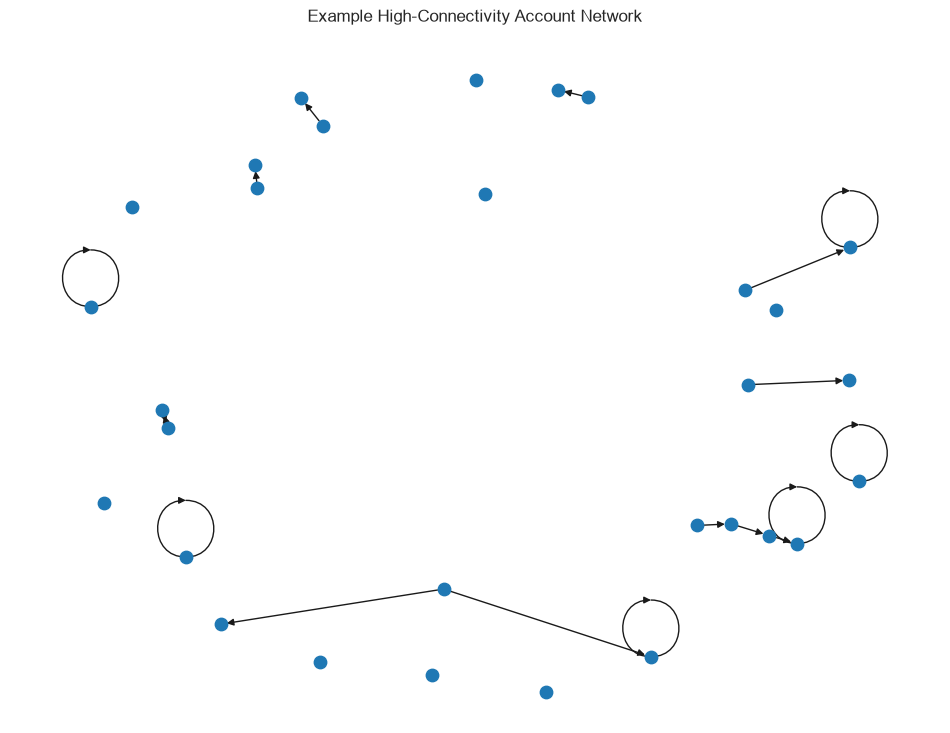

In [9]:
top_nodes=set(
    nodes.nlargest(30,"Degree")["Account_ID"]
)

subgraph=G.subgraph(top_nodes)

plt.figure(figsize=(12,9))
pos=nx.spring_layout(subgraph,seed=42)

nx.draw_networkx(
    subgraph,
    pos,
    with_labels=False,
    node_size=80,
    arrows=True
)

plt.title("Example High-Connectivity Account Network")
plt.axis("off")
save_plot("14-network-visualization.png")
plt.show()

## 15. Fraud Label at Transaction Level

The synthetic data contains a transaction-level label:

```text
Fraud_Label = 1
```

This lets us create a supervised demonstration.

In real banking environments, labels are usually difficult because:

- confirmed fraud arrives with delay,
- investigations may change labels,
- many suspicious cases are never confirmed,
- fraud patterns evolve.

In [10]:
display(
    tx.groupby("Fraud_Label")["Amount"]
      .agg(["count","mean","median","max"])
      .round(2)
)

,count,mean,median,max
Fraud_Label,,,,
0,6938,2189594.84,1152500.0,100000000.0
1,62,2295580.65,1387000.0,18432000.0


## 16. Aggregate Fraud Signal to Accounts

For demonstration, calculate:

```text
Fraudulent outgoing transactions
/
Total outgoing transactions
```

This is a useful analytical feature but would not be available before an investigation outcome in a real-time prediction scenario.

Therefore:

> **Do not use this feature for a production pre-transaction fraud model.**

It is included here only to illustrate network labeling and analysis.

## 17. Build Leakage-Safe Account Features

For a real prediction scenario, use only information available before the prediction timestamp.

Here we use structural and transaction-volume features:

- Degree
- In-degree
- Out-degree
- Total outgoing
- Average outgoing
- Unique beneficiaries
- Incoming transactions
- Total incoming
- Unique senders
- PageRank

In [11]:
model_features=[
    "Degree",
    "In_Degree",
    "Out_Degree",
    "Outgoing_Tx",
    "Total_Outgoing",
    "Avg_Outgoing",
    "Unique_Beneficiaries",
    "Incoming_Tx",
    "Total_Incoming",
    "Unique_Senders",
    "Degree_Centrality",
    "PageRank"
]

# Synthetic account label: whether the account was involved
# in at least one confirmed fraudulent outgoing transaction.
nodes["Fraud_Account"]=(nodes["Fraudulent_Outgoing"]>0).astype(int)

X=nodes[model_features]
y=nodes["Fraud_Account"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=.20,
    stratify=y,
    random_state=42
)

print("Train:",X_train.shape)
print("Test:",X_test.shape)
print("Fraud account rate:",round(y.mean(),3))

Train: (960, 12)
Test: (240, 12)
Fraud account rate: 0.05


## 18. Baseline Graph-Feature ML Model

This is an important distinction:

```text
Graph Analytics
        ↓
Create network features
        ↓
Traditional ML
        ↓
Fraud Risk
```

This is **graph-enhanced machine learning**, but not yet a Graph Neural Network.

It is often a practical starting point because network features are easier to explain and operationalize.

In [12]:
rf=RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

prob=rf.predict_proba(X_test)[:,1]
pred=(prob>=.50).astype(int)

print("ROC-AUC:",round(roc_auc_score(y_test,prob),3))
print("Average Precision:",round(
    average_precision_score(y_test,prob),3
))
print()
print(classification_report(y_test,pred,digits=3))

ROC-AUC: 0.4
Average Precision: 0.045

              precision    recall  f1-score   support

           0      0.947     0.939     0.943       228
           1      0.000     0.000     0.000        12

    accuracy                          0.892       240
   macro avg      0.473     0.469     0.471       240
weighted avg      0.900     0.892     0.896       240



## 19. Feature Importance

Feature importances from the classifier show which network measures contribute most to fraud detection. This tells investigators which structural signals to prioritise in future monitoring rules.


,Feature,Importance
11,PageRank,0.172753
5,Avg_Outgoing,0.151679
4,Total_Outgoing,0.143932
8,Total_Incoming,0.140884
0,Degree,0.058390
2,Out_Degree,0.053611
3,Outgoing_Tx,0.053538
10,Degree_Centrality,0.053007
6,Unique_Beneficiaries,0.051247
7,Incoming_Tx,0.043762


Saved: output/19-feature-importance.png


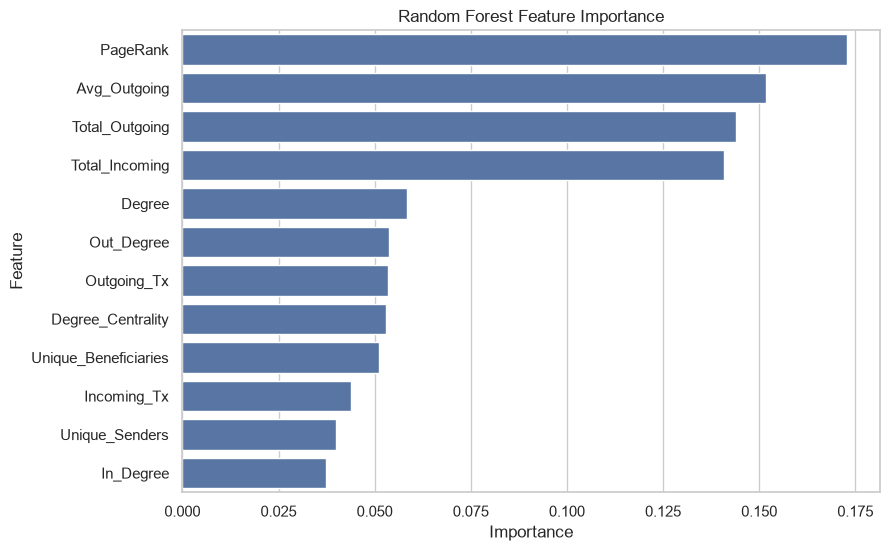

In [13]:
importance=pd.DataFrame({
    "Feature":model_features,
    "Importance":rf.feature_importances_
}).sort_values("Importance",ascending=False)

display(importance)

plt.figure(figsize=(9,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
save_plot("19-feature-importance.png")
plt.show()

## 20. Suspicious Account Ranking

The model produces a risk score.

We can rank accounts:

```text
Account
   ↓
Fraud Risk Score
   ↓
Rank
   ↓
Investigation Queue
```

This is especially useful when investigators have limited capacity.

In [14]:
scored=nodes[[
    "Account_ID",
    "Degree",
    "Out_Degree",
    "Incoming_Tx",
    "Outgoing_Tx"
]].copy()

nodes["Fraud_Risk_Score"]=rf.predict_proba(
    nodes[model_features]
)[:,1]

scored["Fraud_Risk_Score"]=nodes["Fraud_Risk_Score"]

scored=scored.sort_values(
    "Fraud_Risk_Score",
    ascending=False
).reset_index(drop=True)

scored["Risk_Rank"]=np.arange(1,len(scored)+1)

display(scored.head(20))

,Account_ID,Degree,Out_Degree,Incoming_Tx,Outgoing_Tx,Fraud_Risk_Score,Risk_Rank
0,A00912,14,11,3.0,11.0,0.962989,1
1,A00218,8,6,2.0,6.0,0.956605,2
2,A00117,12,9,3.0,9.0,0.954800,3
3,A01055,21,11,10.0,11.0,0.953886,4
4,A00330,12,8,4.0,8.0,0.942529,5
5,A00373,8,6,2.0,6.0,0.931307,6
6,A00987,10,7,3.0,7.0,0.928126,7
7,A00809,8,6,2.0,6.0,0.910830,8
8,A00425,3,2,1.0,2.0,0.906997,9
9,A00660,10,3,7.0,3.0,0.903688,10


## 21. Community Detection

Fraud rings may form communities.

A community is a group of accounts with relatively dense internal relationships.

We can use community detection to identify network structures that deserve investigation.

In [15]:
UG=G.to_undirected()

communities=nx.community.greedy_modularity_communities(UG)

community_map={}

for i,comm in enumerate(communities):
    for node in comm:
        community_map[node]=i

nodes["Community"]=nodes["Account_ID"].map(community_map)

print("Communities:",len(communities))

display(
    nodes["Community"]
    .value_counts()
    .head(10)
    .to_frame("Accounts")
)

Communities: 6


,Accounts
Community,
0,307
1,280
2,234
3,202
4,103
5,74


## 22. Investigate High-Risk Communities

Instead of investigating accounts independently:

```text
Account A
Account B
Account C
```

investigators can inspect:

```text
Community / Network
       ↓
Accounts
       ↓
Transactions
       ↓
Common counterparties
       ↓
Potential ring
```

This can make network investigation more efficient.

In [16]:
community_risk=(
    nodes.groupby("Community")
    .agg(
        Accounts=("Account_ID","count"),
        Avg_Risk=("Fraud_Risk_Score","mean"),
        Max_Risk=("Fraud_Risk_Score","max"),
        Fraud_Accounts=("Fraud_Account","sum")
    )
    .sort_values("Avg_Risk",ascending=False)
)

display(community_risk.head(15).round(3))

,Accounts,Avg_Risk,Max_Risk,Fraud_Accounts
Community,,,,
5,74,0.267,0.867,7
2,234,0.253,0.943,12
4,103,0.252,0.858,5
0,307,0.247,0.957,10
3,202,0.246,0.907,9
1,280,0.240,0.963,17


## 23. Fraud Ring Subgraph

Select a high-risk community and visualize its network.

This is not proof of fraud.

It is an **investigation aid**.

Saved: output/23-fraud-ring-subgraph.png


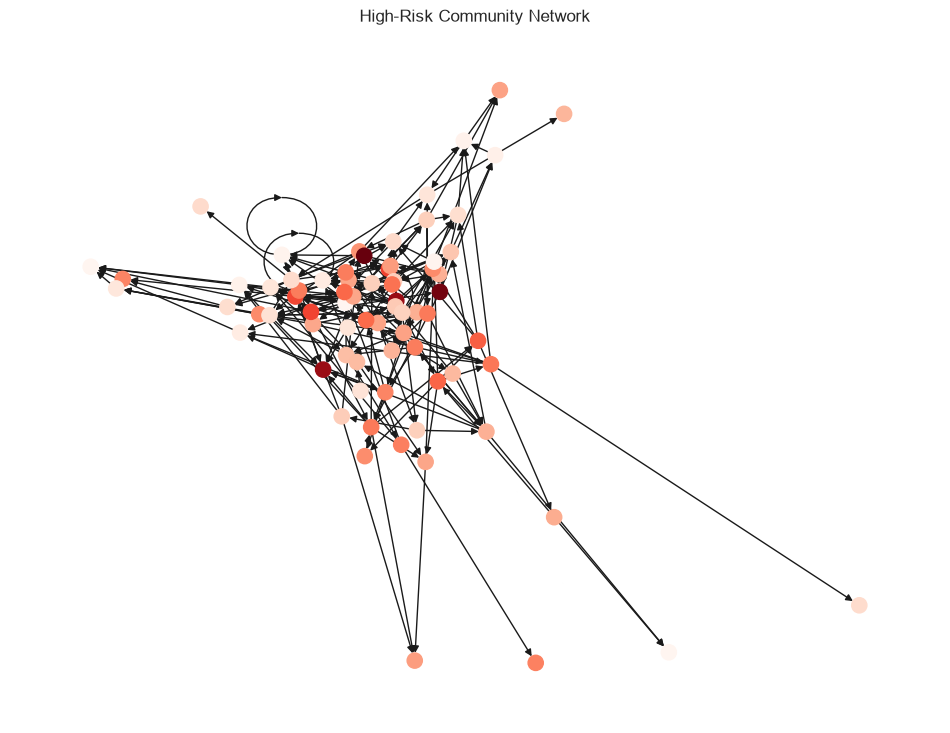

In [17]:
top_community=community_risk.index[0]

community_nodes=set(
    nodes.loc[
        nodes["Community"]==top_community,
        "Account_ID"
    ]
)

community_graph=G.subgraph(community_nodes)

plt.figure(figsize=(12,9))

pos=nx.spring_layout(
    community_graph,
    seed=42
)

node_risk=[
    scored.set_index("Account_ID")
          .loc[n,"Fraud_Risk_Score"]
    for n in community_graph.nodes()
]

nx.draw_networkx(
    community_graph,
    pos,
    with_labels=False,
    node_size=120,
    node_color=node_risk,
    cmap="Reds",
    arrows=True
)

plt.title("High-Risk Community Network")
plt.axis("off")
save_plot("23-fraud-ring-subgraph.png")
plt.show()

## 24. What Makes This "Graph ML"?

There are several levels.

### Level 1 — Graph Analytics

```text
Network
 ↓
Degree
Centrality
Community
```

### Level 2 — Graph Features + ML

```text
Graph
 ↓
Network Features
 ↓
Random Forest / XGBoost / Logistic Regression
```

### Level 3 — Graph Neural Networks

```text
Graph
 ↓
Node / Edge Features
 ↓
Message Passing
 ↓
Graph Neural Network
 ↓
Fraud Prediction
```

This notebook demonstrates Levels 1 and 2 and explains the path toward Level 3.

## 25. Graph Neural Network Concept

A Graph Neural Network allows a node to learn from its neighborhood.

Conceptually:

```text
        B
       ↙ ↘
      A   C
       ↘ ↙
        D
```

For account A:

```text
A's own features
+
B's features
+
C's features
+
relationship structure
        ↓
GNN representation
        ↓
Fraud prediction
```

This is called **message passing**.

## 26. Possible GNN Models

For production research, common approaches include:

### GCN

Graph Convolutional Network

### GraphSAGE

Samples and aggregates neighborhood information.

### GAT

Graph Attention Network.

### GNN for Link Prediction

Predict suspicious relationships:

```text
Should A → B be considered suspicious?
```

### GNN for Node Classification

Predict:

```text
Is account A suspicious?
```

### GNN for Graph Classification

Predict whether an entire subgraph represents a fraud pattern.

## 27. Fraud Detection as Node Classification

A common Graph ML formulation:

```text
Node
=
Bank Account

Features
=
Account behavior

Edges
=
Transactions

Target
=
Fraud / Normal
```

The GNN learns:

```text
Account behavior
+
Neighborhood behavior
+
Network structure
        ↓
Fraud probability
```

This is often more expressive than treating every account independently.

## 28. Fraud Detection as Link Prediction

Another formulation:

```text
A → B
```

The model predicts whether the relationship is suspicious.

Useful when the primary question is:

> **"Is this transaction / relationship suspicious?"**

Features can include:

- transaction amount,
- frequency,
- historical relationship,
- shared counterparties,
- neighborhood embeddings,
- temporal behavior.

## 29. Temporal Graph Challenge

Banking networks change over time.

Example:

```text
January
A → B

February
A → C

March
A → D

April
B → D
```

A production system should preserve temporal information.

Otherwise:

> Future transactions can accidentally leak into historical predictions.

This is a major issue in graph fraud detection.

## 30. Evaluation

Useful metrics include:

### Classification

- ROC-AUC
- PR-AUC
- Precision
- Recall
- F1

### Ranking

- Precision@K
- Recall@K
- Lift@K

### Graph-specific operational metrics

- suspicious ring detection rate
- investigation yield
- confirmed fraud amount
- false-positive investigation volume
- alert reduction
- time-to-detection

## 31. Why PR-AUC Matters

Fraud is often rare.

Imagine:

```text
100,000 transactions
99,000 normal
1,000 fraud
```

Accuracy can be misleading.

A model predicting everything as normal would have:

```text
99% accuracy
```

but:

```text
0 fraud detected
```

Therefore precision-recall metrics are often important for imbalanced fraud problems.

## 32. Production Architecture

```text
Transaction Stream
        ↓
Graph Construction
        ↓
Graph Feature Store
        ↓
Graph Analytics
        ↓
Graph ML / GNN
        ↓
Fraud Risk Score
        ↓
Rules + Risk Engine
        ↓
Alert / Block / Review
        ↓
Fraud Investigation
        ↓
Confirmed Labels
        ↓
Model Retraining
```

For real-time fraud, the graph must support continuously changing relationships.

## 33. Important Banking Controls

Fraud detection is a high-impact banking system.

Production implementation requires:

- explainability,
- audit trails,
- data governance,
- access control,
- privacy protection,
- model monitoring,
- human investigation,
- false-positive management,
- regulatory compliance.

A model score should generally be treated as an input to an investigation/risk process rather than automatically treated as proof of fraud.

## 34. Common Mistakes

1. Treating a graph as a simple table.
2. Ignoring edge direction.
3. Ignoring time.
4. Data leakage through future transactions.
5. Using confirmed fraud labels incorrectly.
6. Over-relying on centrality.
7. Assuming a highly connected account is fraudulent.
8. Ignoring false positives.
9. Evaluating only ROC-AUC.
10. Treating network association as proof of fraud.

## 35. Final Executive Summary

### Business Question

> **Can relationships between accounts help identify fraud?**

### Graph Representation

```text
Accounts
   ↓
Nodes

Transactions
   ↓
Edges
```

### Analytical Pipeline

```text
Transactions
     ↓
Network
     ↓
Graph Features
     ↓
Community Detection
     ↓
ML Risk Model
     ↓
Fraud Risk Ranking
     ↓
Suspicious Network Investigation
```

### Advanced Direction

```text
Graph Features + ML
        ↓
Graph Neural Network
        ↓
Node / Edge / Subgraph Fraud Detection
```

### Main Takeaway

> **Graph ML adds relationship intelligence to fraud detection.**

Traditional ML asks:

> "Does this account/transaction look suspicious?"

Graph ML adds:

> **"Does this account/transaction look suspicious given its relationships and surrounding network?"**

That network perspective is particularly valuable for detecting coordinated activity and potential fraud rings.

## 36. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [18]:
nodes.to_csv(OUTPUT_DIR / "account_network_features.csv", index=False)
print("Saved:", OUTPUT_DIR / "account_network_features.csv")
scored.to_csv(OUTPUT_DIR / "suspicious_account_ranking.csv", index=False)
print("Saved:", OUTPUT_DIR / "suspicious_account_ranking.csv")
community_risk.to_csv(OUTPUT_DIR / "community_risk_ranking.csv", index=False)
print("Saved:", OUTPUT_DIR / "community_risk_ranking.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/account_network_features.csv
Saved: output/suspicious_account_ranking.csv
Saved: output/community_risk_ranking.csv
  output/14-network-visualization.png
  output/19-feature-importance.png
  output/23-fraud-ring-subgraph.png
  output/account_network_features.csv
  output/community_risk_ranking.csv
  output/suspicious_account_ranking.csv
